# Data Analysis and EDA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/ICT/Files/owid-covid-data.csv'
df = pd.read_csv(file_path)

df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,gdp_per_capita,extreme_poverty,cardiovasc_death_rate,diabetes_prevalence,female_smokers,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index
0,AFG,Asia,Afghanistan,2019-12-31,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
1,AFG,Asia,Afghanistan,2020-01-01,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
2,AFG,Asia,Afghanistan,2020-01-02,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
3,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498
4,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,...,1803.987,NaN,597.029,9.59,NaN,NaN,37.746,0.5,64.83,0.498


In [ ]:
df = df.drop(columns=['iso_code','location','continent','date'], errors='ignore')

In [ ]:
target = 'new_cases'

In [ ]:
leakage_cols = [
    'new_cases_smoothed',
    'new_cases_per_million',
    'new_cases_smoothed_per_million',
    'total_cases'
]

df = df.drop(columns=leakage_cols, errors='ignore')

**Columns to drop (very weak)**

- gdp_per_capita (Negligible correlation with target variable)

- extreme_poverty (Very weak correlation with target and high missing percentage)

- cardiovasc_death_rate (Negligible linear relationship with daily new cases)


- hospital_beds_per_thousand (Weak correlation and limited immediate impact on daily case variation)

- handwashing_facilities (lots of missing values, about 58%)



**Columns to Keep**

- female_smokers (Useful since COVID is a Respiratory System affecting disease)

- male_smokers (Useful since COVID is a Respiratory System affecting disease)

- human_development_index (Relatively higher correlation and strong socioeconomic relevance)

- life_expectancy (Public health relevance despite weak direct correlation)

- diabetes_prevalence (Epidemiologically relevant risk factor influencing COVID outcomes)


- new_cases_per_million
- new_cases_smoothed_per_million
- total_deaths_per_million
- new_deaths_per_million
- new_deaths_smoothed_per_million
- total_tests_per_thousand
- new_tests_per_thousand
- new_tests_smoothed
- new_tests_smoothed_per_thousand

Removing these columns to avoid
- data leakage
- redundancy
- multicollinearity as those are either derived/scaled from the main raw column

This does not add any new information.

Thus keeping only these 2 columns as our target is new_cases which is raw data.
- new_tests- No.of new tests conducted on that specific day.
- total_tests- The total number of tests conducted up to that date.

From this also choosing new_tests only as total tests is cumulative sum.

Highly correlated (values > 0.8–0.9) implies data redundancy and multicollinearity and very weak correlation means that feature is not that important for prediction ie limited linear predictive power in the current dataset.Here weak correlation is due to the dataset being only of the year 2020 which alone is not enough for our present entire covid picture and also due to reporting differences.


- new tests is rightly skewed- has a long tail on the right
- 65% missing hence dropping it as median filling will not be suitable and will mislead
- Filling would artificially assign the same testing value to a large proportion of observations
- no dropna as it will give only remaining 15k rows which removes so much data and hence if we drop the entire column it wont affect
- Making dataset biased towards countries that report high testing

Columns to drop:


*   aged_65_older'
*   aged_70_older
- The correlation matrix shows a very strong positive correlation (around 0.95) among median_age, aged_65_older, and aged_70_older. This indicates that these variables move together and represent similar demographic characteristics of a country
- scatter plots,  a clear upward linear pattern between the age variables. The data points are closely clustered along a straight line, indicating a strong positive linear relationship. This visually confirms the high correlation observed numerically.

*   Positive rate
*   test per cases
- positive_rate and tests_per_case because they are mathematically derived from case-related variables and may cause data leakage
- tests_per_case = total_tests / new_cases.
positive_rate = new_cases / total_tests , positive_rate already contains new_cases inside it.
- Based on the scatter plots, both positive_rate and tests_per_case show structured dependency patterns with new_cases rather than independent random relationships. This occurs because both variables are mathematically derived from case-related values. Therefore, keeping them in the model may introduce data leakage and redundancy. Hence, they were dropped from the analysis.






In [ ]:
drop_cols = [
    'tests_per_case',
    'positive_rate',
    'aged_65_older',
    'aged_70_older',
    'gdp_per_capita',
    'extreme_poverty',
    'cardiovasc_death_rate',
    'hospital_beds_per_thousand',
    'handwashing_facilities',
    'new_cases_per_million',
    'new_cases_smoothed_per_million',
    'total_deaths_per_million',
    'new_deaths_per_million',
    'new_tests',
    'total_tests',
    'total_tests_per_thousand',
    'new_tests_per_thousand',
    'new_tests_smoothed',
    'new_tests_smoothed_per_thousand',
    'new_cases_smoothed',
    'total_cases',
    'total_cases_per_million',
    'total_deaths',
    'new_deaths',
    'new_deaths_smoothed',
    'new_deaths_smoothed_per_million',
    'tests_units'
]

In [ ]:
df_clean = df.drop(columns=drop_cols, errors='ignore')

In [ ]:
num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

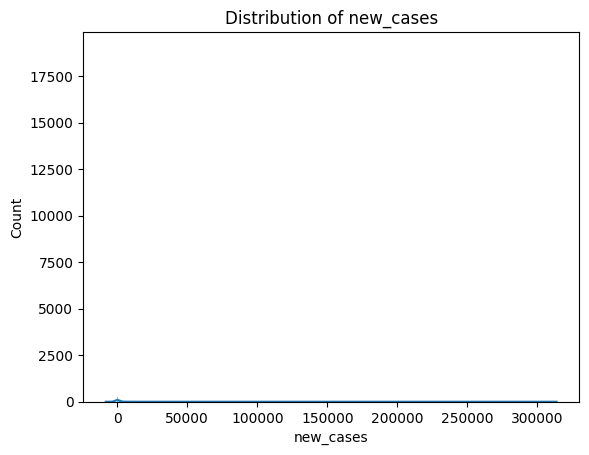

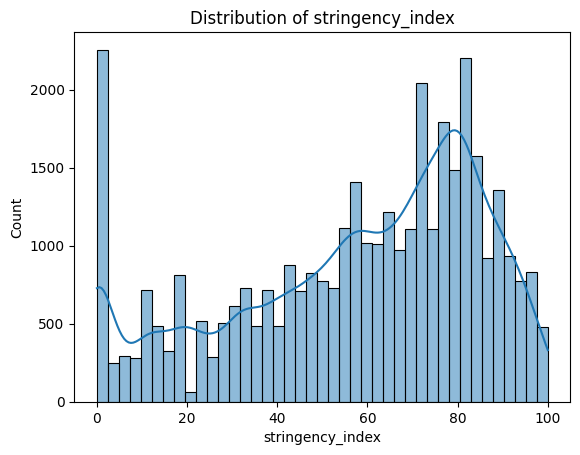

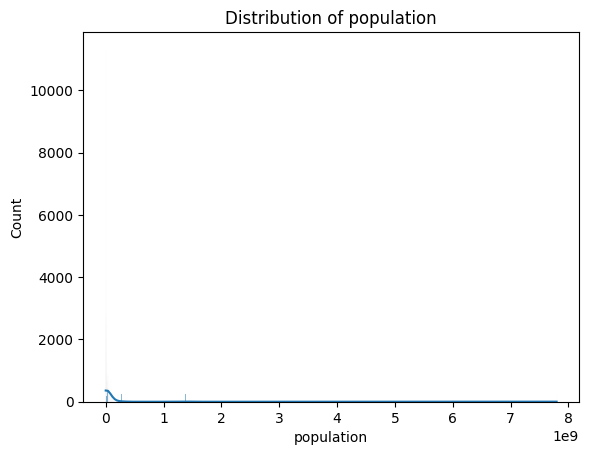

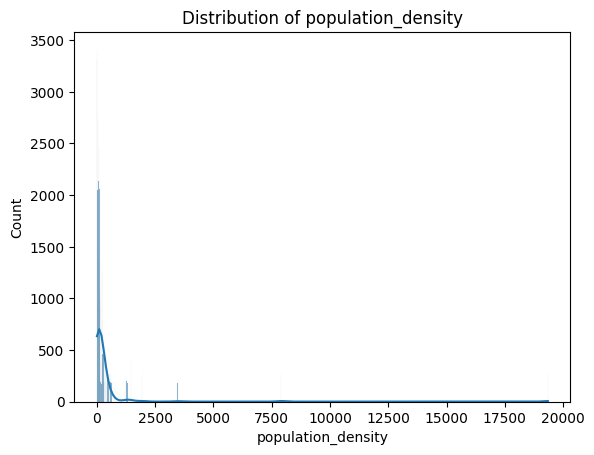

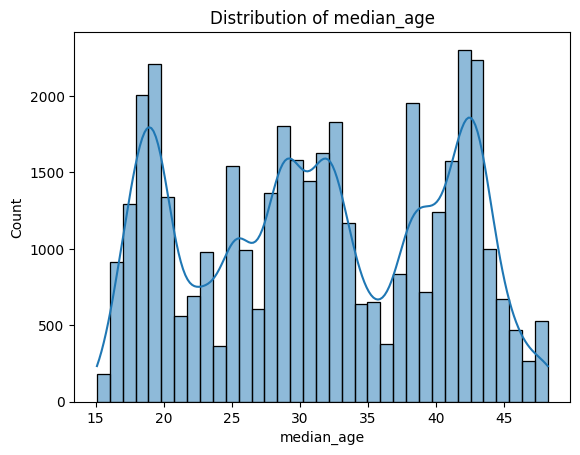

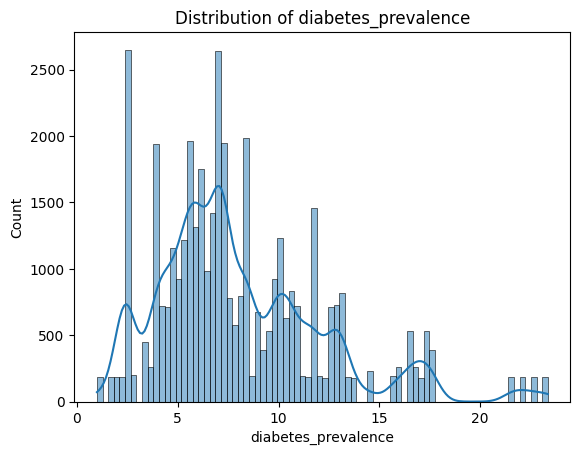

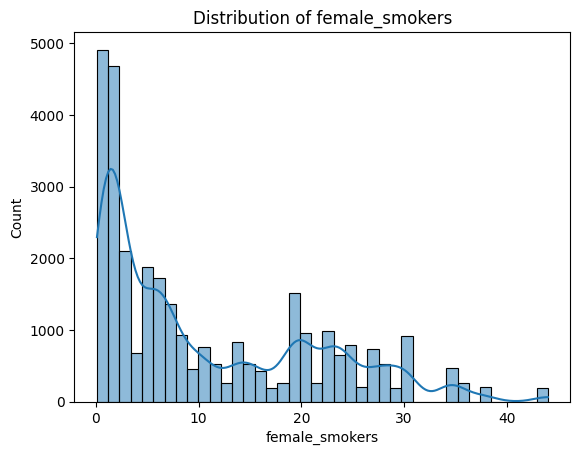

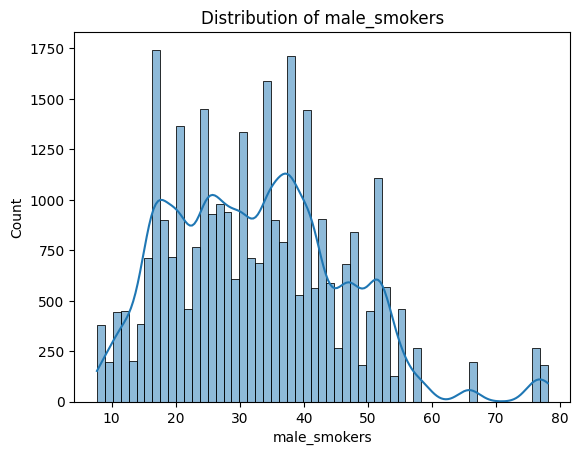

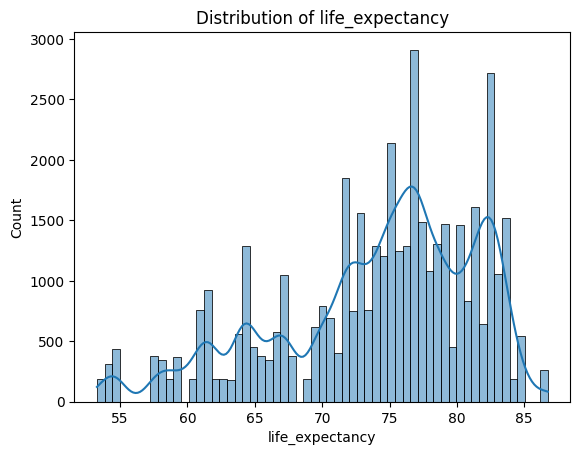

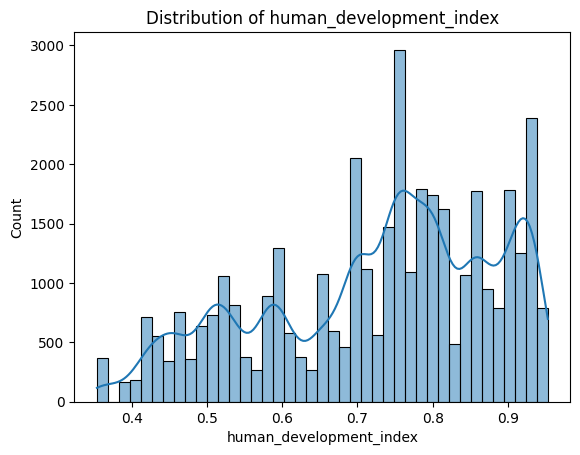

In [ ]:
for col in num_cols:
    plt.figure()
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

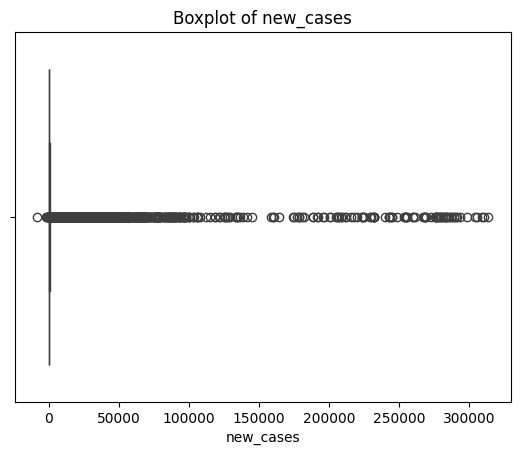

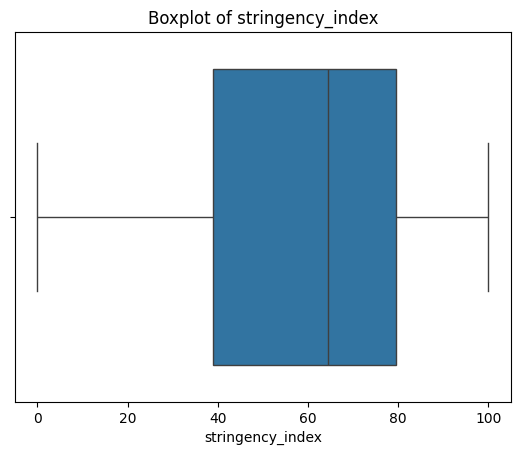

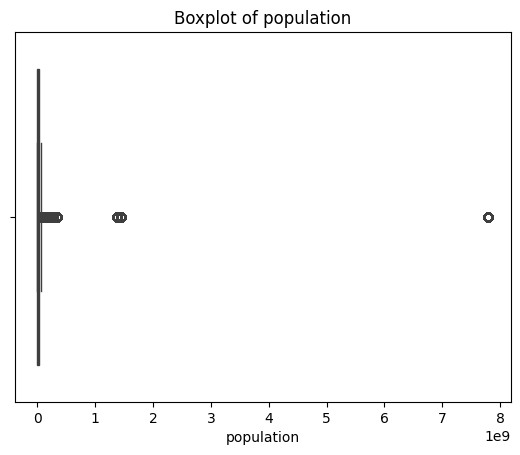

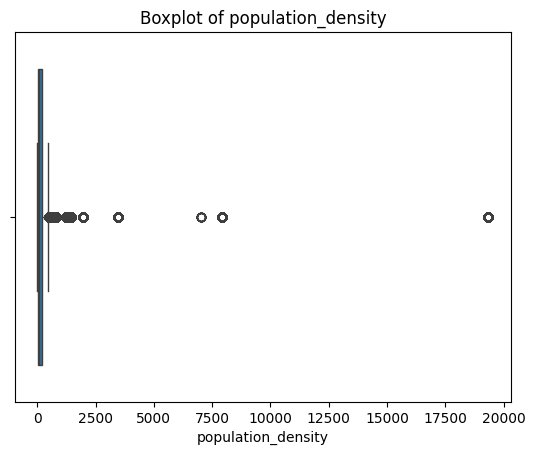

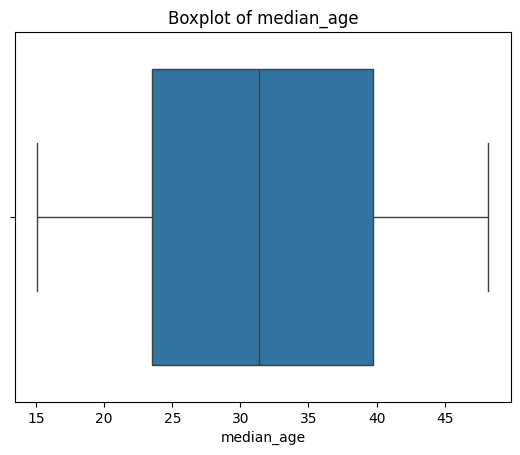

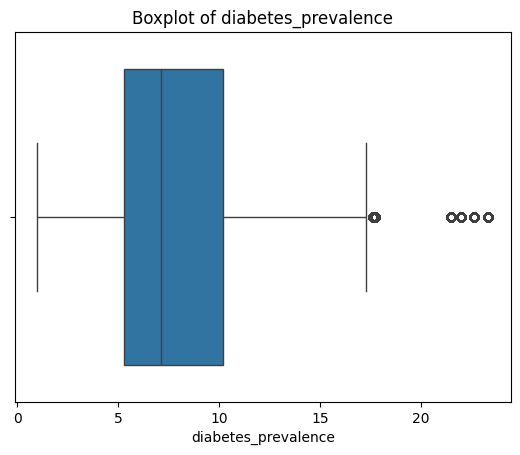

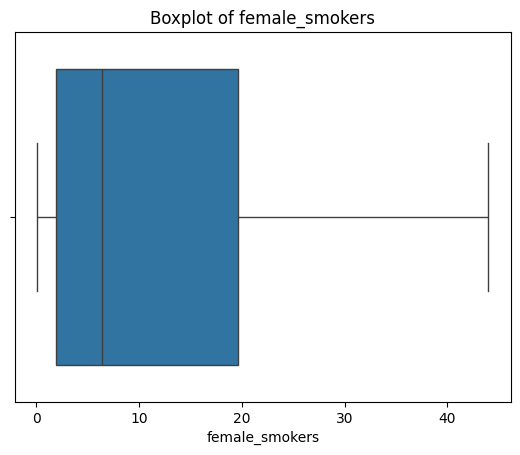

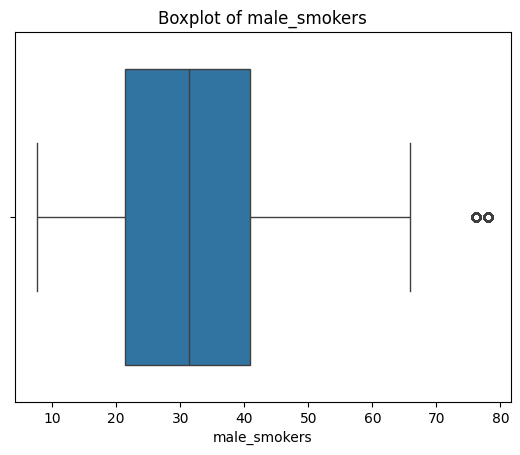

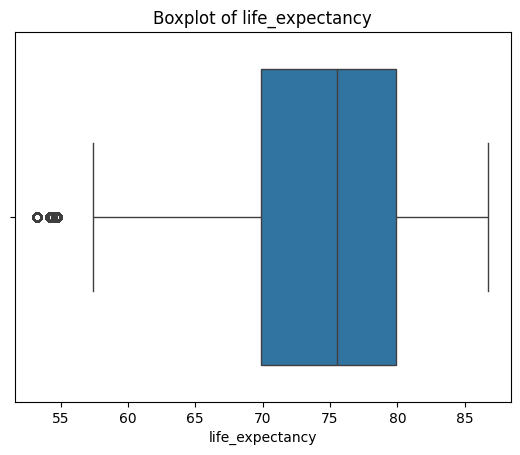

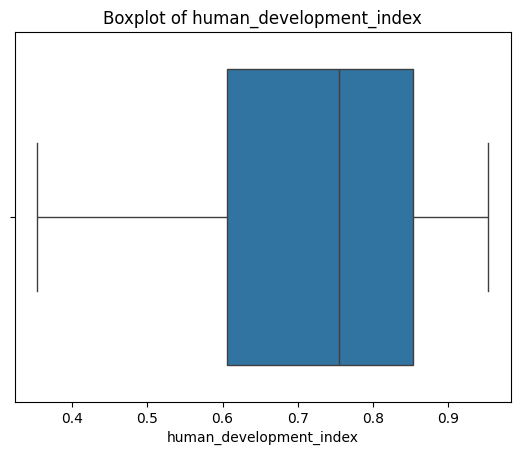

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
num_cols = num_cols.drop('new_cases')

# Preprocessing

In [ ]:
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [ ]:
# Log transform highly skewed features
skew_cols = ['population', 'population_density']

for col in skew_cols:
    if col in df_clean.columns:
        df_clean[col] = np.log1p(df_clean[col])

# Log transform target (important because distribution is extremely skewed)
def safe_log1p(series):
    # replace negative values with NaN (log undefined)
    series = series.copy()
    series[series < 0] = np.nan
    return np.log1p(series)

for col in ['population', 'population_density']:
    if col in df_clean.columns:
        df_clean[col] = safe_log1p(df_clean[col])

# target transform
df_clean['new_cases_log'] = np.log1p(df_clean['new_cases'].clip(lower=0))

# Mild IQR capping for moderate outliers
def cap_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in ['diabetes_prevalence', 'male_smokers']:
    if col in df_clean.columns:
        df_clean[col] = cap_iqr(df_clean[col])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

In [ ]:
df_clean.head()

,new_cases,stringency_index,population,population_density,median_age,diabetes_prevalence,female_smokers,male_smokers,life_expectancy,human_development_index,new_cases_log
0,0.0,0.217720,0.755005,-0.186457,-1.497956,0.465098,-0.344843,-0.05363,-1.267165,-1.631195,0.0
1,0.0,-2.320798,0.755005,-0.186457,-1.497956,0.465098,-0.344843,-0.05363,-1.267165,-1.631195,0.0
2,0.0,-2.320798,0.755005,-0.186457,-1.497956,0.465098,-0.344843,-0.05363,-1.267165,-1.631195,0.0
3,0.0,-2.320798,0.755005,-0.186457,-1.497956,0.465098,-0.344843,-0.05363,-1.267165,-1.631195,0.0
4,0.0,-2.320798,0.755005,-0.186457,-1.497956,0.465098,-0.344843,-0.05363,-1.267165,-1.631195,0.0


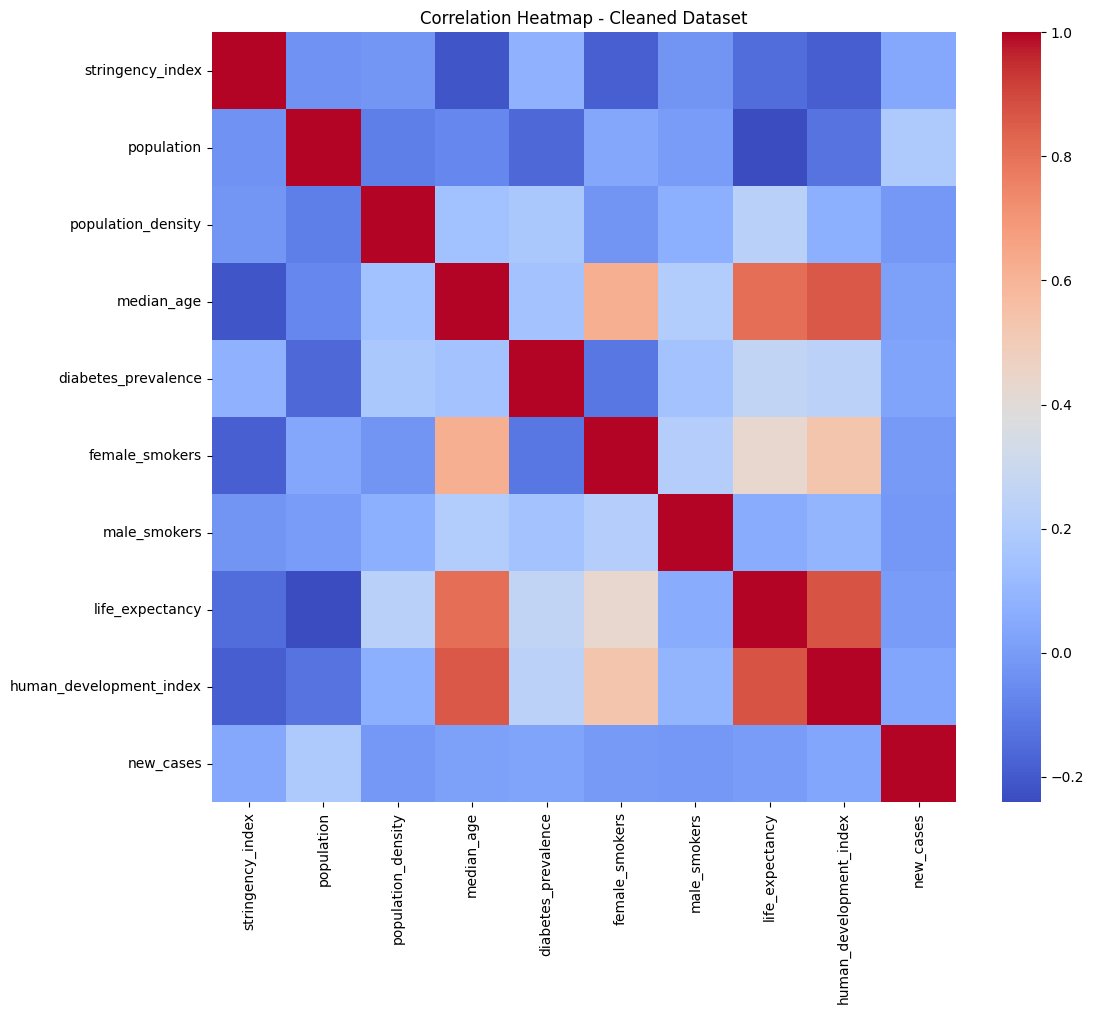

In [ ]:
corr_matrix = df_clean[num_cols.tolist() + ['new_cases']].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Correlation Heatmap - Cleaned Dataset')
plt.show()

In [ ]:
df_clean = df_clean.dropna(subset=['new_cases_log'])

In [ ]:
# Target variable
y = df_clean['new_cases_log']

# Features (everything except target)
X = df_clean.drop(columns=['new_cases', 'new_cases_log'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (35185, 9)
Test set: (8797, 9)


In [ ]:
y_test

#

,new_cases_log
29994,4.890349
8251,0.000000
12873,0.000000
2588,4.499810
9579,7.102499
...,...
21910,6.551080
27875,1.945910
34553,0.000000
11993,0.000000


# Model Selection and Tuning

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("R2:", r2)
    print("-" * 30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")

Linear Regression
MAE: 1.6524243414195883
RMSE: 2.0168326527285867
R2: 0.4821689971766101
------------------------------
Decision Tree
MAE: 0.7100625191625056
RMSE: 1.1377055324007534
R2: 0.8352186485998291
------------------------------
Random Forest
MAE: 0.7100695282459155
RMSE: 1.1351350416028236
R2: 0.8359624095066769
------------------------------


Random Forest achieved the lowest error and highest explanatory power, making it the most suitable model.

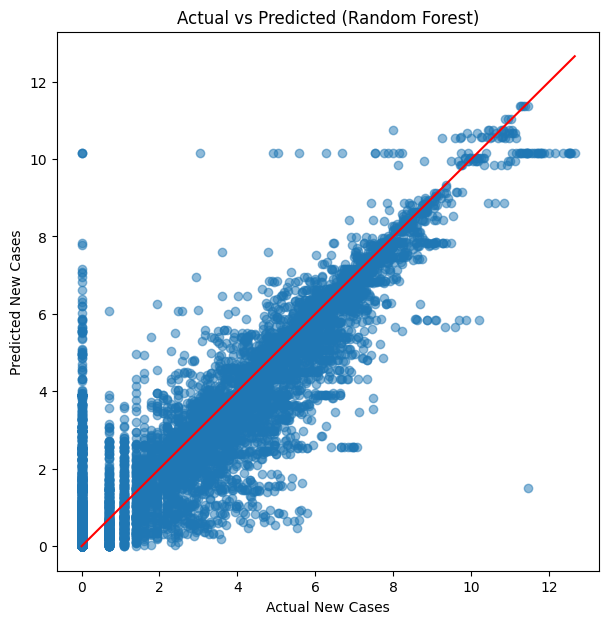

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual New Cases")
plt.ylabel("Predicted New Cases")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(random_state=42)

scores = cross_val_score(
    rf, X, y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print("RMSE scores:", -scores)
print("Mean RMSE:", -scores.mean())

RMSE scores: [2.16776458 2.06271777 2.09238249 2.1808092  2.59179295]
Mean RMSE: 2.219093397112315


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
best_rf = grid_search.best_estimator_

Best parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
y_pred_best = best_rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("Tuned Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))
print("R2:", r2_score(y_test, y_pred_best))

Tuned Random Forest
MAE: 0.7138359521602159
RMSE: 1.1351895835315844
R2: 0.8359466454941293


In [ ]:
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Tuned RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

Baseline RMSE: 1.1351350416028236
Tuned RMSE: 1.1351895835315844


-

In [ ]:
import pickle

with open("covid_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)